# A/E analysis refactor test notebook

这个 notebook 用来快速测试 `aoe_analysis_refactor.py` 里的核心函数是否能正常工作。

建议流程：
1. 先运行导入区
2. 检查 `run_db` 和 `lh5` 是否已经存在
3. 检查字段名
4. 跑统计测试
5. 跑单个 run 的画图测试


In [2]:
# 如果你的 .py 文件和 notebook 在同一目录，直接这样导入即可
# 如果不在同一目录，请取消下面两行注释并改成你的路径
# import sys
# sys.path.append(r"你的py文件所在目录")

from importlib import reload
import aoe_analysis_utils as ref
reload(ref)

from aoe_analysis_utils import *
print('refactor module loaded')


refactor module loaded


In [ ]:
import numpy as np
import awkward as ak
from lgdo import lh5
import os
import re

filepath = "/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

pnum_cal = "00"
run_cal = "037"

pnum_phy_bg = "00"
run_phy_bg = "038"

pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7'
]

def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)
        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")

        missing_this_run = []

        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")

        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "interval": f"{m.group(1)}ns",
            "mw": f"mw{m.group(2)}",

            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,

            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,

            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )

    return db
run_db = build_run_db(runs, filepath)

## 先确认你的环境里已经有这两个对象

- `run_db`
- `lh5`

如果还没有，请先在你原来的 notebook 前面运行构建 `run_db` 和初始化 `lh5` 的代码。

In [4]:
print('run_db exists:', 'run_db' in globals())
print('lh5 exists  :', 'lh5' in globals())

if 'run_db' in globals():
    print('number of runs:', len(run_db))
    print('run keys:', list(run_db.keys())[:10])


run_db exists: True
lh5 exists  : True
number of runs: 12
run keys: ['s100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7', 's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7', 's60ns_mw1', 's60ns_mw3']


## 选一个测试 run

默认优先选 `s100ns_mw3`，如果没有就自动选第一个。

In [6]:
preferred_run = 's100ns_mw3'

if preferred_run in run_db:
    test_run = preferred_run
else:
    test_run = list(run_db.keys())[0]

info = run_db[test_run]
print('test_run =', test_run)
print(info)


test_run = s100ns_mw3
{'run': 's100ns_mw3', 'interval': '100ns', 'mw': 'mw3', 'phy_bg_path': '/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs/s100ns_mw3/phy/p00/r038', 'phy_signal_path': '/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs/s100ns_mw3/phy/p05/r059', 'cal_path': '/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs/s100ns_mw3/cal/p00/r037', 'phy_bg_files': ['sp01-p00-r038-phy-20231027T170002Z-tier_hit.lh5', 'sp01-p00-r038-phy-20231027T173002Z-tier_hit.lh5', 'sp01-p00-r038-phy-20231027T180001Z-tier_hit.lh5', 'sp01-p00-r038-phy-20231027T183001Z-tier_hit.lh5', 'sp01-p00-r038-phy-20231027T190001Z-tier_hit.lh5', 'sp01-p00-r038-phy-20231027T193001Z-tier_hit.lh5', 'sp01-p00-r038-phy-20231027T200001Z-tier_hit.lh5', 'sp01-p00-r038-phy-20231027T203001Z-tier_hit.lh5', 'sp01-p00-r038-phy-20231027T210001Z-tier_hit.lh5', 'sp01-p00-r038-phy-20231027T213001Z-tier_hit.lh5', 'sp01-p00-r038-phy-20231027T220002Z-tier_hit.lh5', 'sp01-p00-r038-phy-20231027T223001Z-tier_hit.lh5', 'sp01-p00-r038-phy-202

## 检查 cal / phy_bg / phy_signal 的字段

你最常见的问题就是 A/E 字段名不一致，所以这里先看一下有哪些字段。

In [7]:
cal_fields = get_available_fields(lh5, 'ch001/hit', info['cal_pathlist'])
bg_fields = get_available_fields(lh5, 'ch001/hit', info['phy_bg_pathlist'])
signal_fields = get_available_fields(lh5, 'ch001/hit', info['phy_signal_pathlist'])

print('cal fields:')
print(cal_fields)
print('\nphy_bg fields:')
print(bg_fields)
print('\nphy_signal fields:')
print(signal_fields)


cal fields:
['A_max_mw_o_E_Classifier', 'A_max_mw_o_E_Corrected', 'A_max_mw_o_E_Double_Sided_Cut', 'A_max_mw_o_E_High_Side_Cut', 'A_max_mw_o_E_Low_Cut', 'A_max_mw_o_E_Timecorr', 'A_max_mw_o_E_Uncorr', 'A_max_mw_o_E_fix_Classifier', 'A_max_mw_o_E_fix_Corrected', 'A_max_mw_o_E_fix_Double_Sided_Cut', 'A_max_mw_o_E_fix_High_Side_Cut', 'A_max_mw_o_E_fix_Low_Cut', 'A_max_mw_o_E_fix_Timecorr', 'A_max_mw_o_E_fix_Uncorr', 'A_max_o_E_Classifier', 'A_max_o_E_Corrected', 'A_max_o_E_Double_Sided_Cut', 'A_max_o_E_High_Side_Cut', 'A_max_o_E_Low_Cut', 'A_max_o_E_Timecorr', 'A_max_o_E_Uncorr', 'A_max_o_E_fix_Classifier', 'A_max_o_E_fix_Corrected', 'A_max_o_E_fix_Double_Sided_Cut', 'A_max_o_E_fix_High_Side_Cut', 'A_max_o_E_fix_Low_Cut', 'A_max_o_E_fix_Timecorr', 'A_max_o_E_fix_Uncorr', 'A_max_tri_o_E_Classifier', 'A_max_tri_o_E_Corrected', 'A_max_tri_o_E_Double_Sided_Cut', 'A_max_tri_o_E_High_Side_Cut', 'A_max_tri_o_E_Low_Cut', 'A_max_tri_o_E_Timecorr', 'A_max_tri_o_E_Uncorr', 'A_max_tri_o_E_fix_Classif

## 自动挑一个可能存在的 A/E 字段

这里会按候选列表自动找。你也可以手动改。

In [ ]:
aoe_candidates = [
    'A_max_mw_o_E_Corrected',
    'Amax_o_E_Corrected',
    'A_max_mw_o_E',
    'Amax_o_E',
]

energy_candidates = [
    'trapEftp_cal',
    'trapEftp',
]

def pick_first_existing(candidates, available_fields):
    for f in candidates:
        if f in available_fields:
            return f
    return None

aoe_field = pick_first_existing(aoe_candidates, cal_fields)
energy_field = pick_first_existing(energy_candidates, cal_fields)

print('chosen aoe_field   =', aoe_field)
print('chosen energy_field=', energy_field)


## 测试直接读取数组

In [ ]:
E_cal = read_array_from_run(
    run_db,
    test_run,
    lh5,
    dataset='cal',
    channel='ch001',
    table='hit',
    field=energy_field,
)

aoe_cal = read_array_from_run(
    run_db,
    test_run,
    lh5,
    dataset='cal',
    channel='ch001',
    table='hit',
    field=aoe_field,
)

print('len(E_cal)   =', len(E_cal))
print('len(aoe_cal) =', len(aoe_cal))
print('E_cal[:5]    =', E_cal[:5])
print('aoe_cal[:5]  =', aoe_cal[:5])


## 跑单个 key 的 low-A/E 统计测试

In [ ]:
single_key_result = count_low_aoe_for_key(
    info,
    lh5,
    key='phy_bg_ch001',
    roi_min=1839,
    roi_max=2239,
    aoe_cut=0.20,
    energy_field=energy_field,
    aoe_field=aoe_field,
)

single_key_result


## 跑单个 run 的全部统计

In [ ]:
window = info['interval']
mw = info['mw']

single_run_result = count_low_aoe_in_roi(
    run_db,
    window=window,
    mw=mw,
    lh5=lh5,
    roi_min=1839,
    roi_max=2239,
    aoe_cut=0.20,
    energy_field=energy_field,
    aoe_field=aoe_field,
)

single_run_result


## 跑全部 run 的统计

第一次建议先别跑，确认上面都没问题再打开。

In [ ]:
# summary = count_low_aoe_all_runs(
#     run_db,
#     lh5,
#     roi_min=1839,
#     roi_max=2239,
#     aoe_cut=0.20,
#     energy_field=energy_field,
#     aoe_field=aoe_field,
# )
# 
# summary


## 单个 run 画图测试

注意：`plot_aoe_for_run_lowmem` 这里要求传入的 `window` 形如 `100ns`，`mw` 形如 `mw3`。

In [1]:
run_db.keys()

NameError: name 'run_db' is not defined

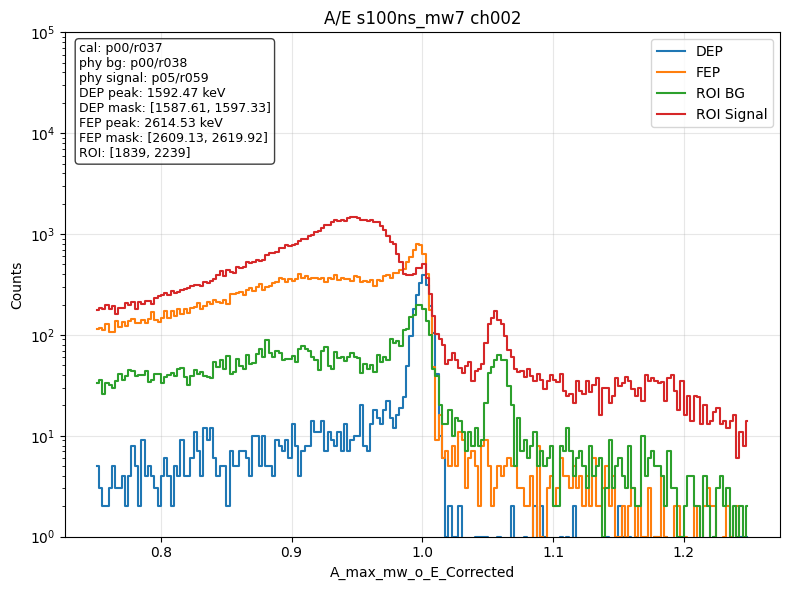

dict_keys(['DEP', 'FEP', 'ROI_BG', 'ROI_Signal', 'meta'])

In [8]:
hist_db = plot_aoe_for_run_lowmem(
    run_db,
    window="100ns",
    mw="mw7",
    lh5=lh5,
    index=1,
    do_peak_plot=False, # 想看 peak 拟合就改 True
    use_fitted_peaks=True,# 默认就是 True
    ylim_top=1e5
)
hist_db.keys()


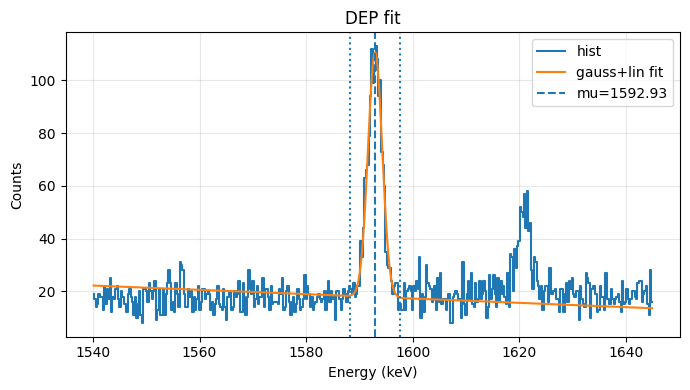

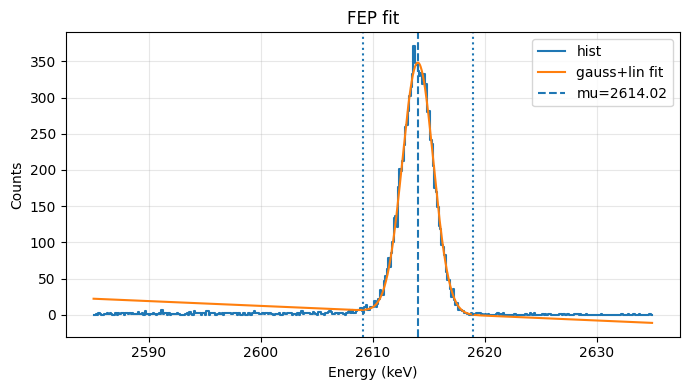

In [14]:
peak_db = get_peak_db_for_run(
    run_db=run_db,
    run="s100ns_mw3",
    lh5=lh5,
    index=0,
    do_plot=False,
    use_cache=True,
)

plot_peak_fit_result(peak_db["DEP"], title="DEP fit")
plot_peak_fit_result(peak_db["FEP"], title="FEP fit")

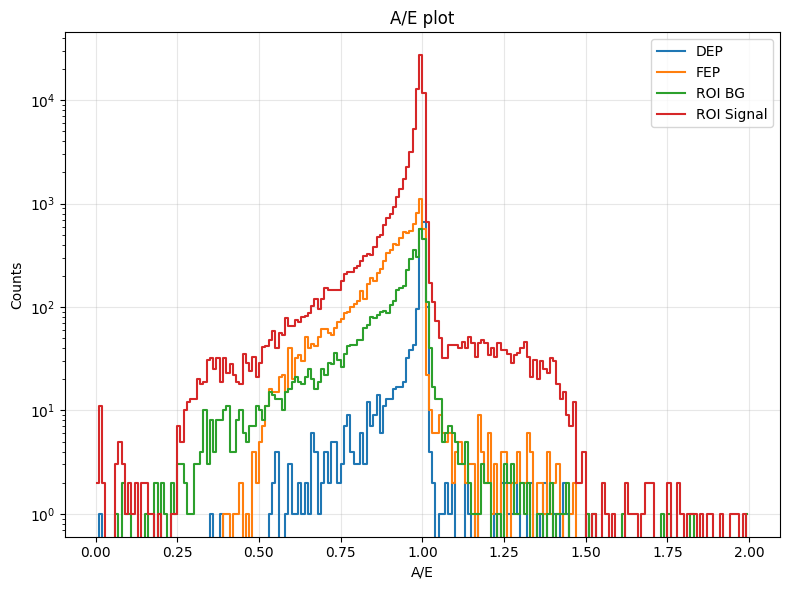

In [16]:
from matplotlib import pyplot as plt

plt.figure(figsize=(8, 6))

label_map = {
    "DEP": "DEP",
    "FEP": "FEP",
    "ROI_BG": "ROI BG",
    "ROI_Signal": "ROI Signal",
}

for key, label in label_map.items():
    plt.step(
        hist_db[key]["centers"],
        hist_db[key]["counts"],
        where="mid",
        label=label
    )

plt.yscale("log")
plt.xlabel("A/E")
plt.ylabel("Counts")
plt.title("A/E plot")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 可选：保存统计结果

In [9]:
def run_all_aoe_plots(
    run_db,
    lh5,
    indices=(1,2),
    do_peak_plot=False,
    use_fitted_peaks=True,
    save_results=False,
    output_dir=None,
    close_figures=True,
    **plot_kwargs,
):
    """
    Loop over all runs (and channels) and make A/E plots.

    Parameters
    ----------
    run_db : dict
        Output of build_run_db().
    lh5 : object
        LH5 reader handle.
    indices : tuple
        Channels to process: 0 -> ch001, 1 -> ch002
    do_peak_plot : bool
        If True, also show DEP/FEP fit plots before A/E plot.
    use_fitted_peaks : bool
        If True, use fitted DEP/FEP windows.
    save_results : bool
        If True, save result db as pickle.
    output_dir : str or None
        If not None, save pickle into this folder.
    close_figures : bool
        If True, call plt.close('all') after each run/channel.
    **plot_kwargs :
        Passed into plot_aoe_for_run_lowmem(), e.g.
        binnum=200, ylim_top=1e6, aoe_field=..., energy_field=...

    Returns
    -------
    all_results : dict
        Nested dict:
        all_results[run][channel] = {
            "status": "ok" / "fail",
            "peak_db": ...,
            "hist_db": ...,
            "error": ...
        }
    """
    import os
    import gc
    import pickle
    import matplotlib.pyplot as plt

    all_results = {}

    for run in sorted(run_db.keys()):
        print(f"\n========== processing {run} ==========")
        all_results[run] = {}

        # parse run name like s100ns_mw3 -> window="100ns", mw="mw3"
        m = re.match(r"s(\d+ns)_?(mw\d+)", run)
        if m is None:
            # fallback for exact pattern s100ns_mw3
            m2 = re.match(r"s(\d+)ns_(mw\d+)", run)
            if m2 is None:
                print(f"[FAIL] could not parse run name: {run}")
                for index in indices:
                    channel = get_channel(index=index)
                    all_results[run][channel] = {
                        "status": "fail",
                        "peak_db": None,
                        "hist_db": None,
                        "error": f"could not parse run name: {run}",
                    }
                continue
            window = f"{m2.group(1)}ns"
            mw = m2.group(2)
        else:
            window = m.group(1)
            mw = m.group(2)

        for index in indices:
            channel = get_channel(index=index)
            print(f"--- {run} | {channel} ---")

            try:
                peak_db = None
                if use_fitted_peaks:
                    peak_db = get_peak_db_for_run(
                        run_db=run_db,
                        run=run,
                        lh5=lh5,
                        index=index,
                        energy_field=plot_kwargs.get("energy_field", "trapEftp_cal"),
                        do_plot=False,
                        use_cache=True,
                    )

                    if do_peak_plot:
                        plot_peak_fit_result(
                            peak_db["DEP"],
                            title=f"{run} | {channel} | DEP fit"
                        )
                        plot_peak_fit_result(
                            peak_db["FEP"],
                            title=f"{run} | {channel} | FEP fit"
                        )

                hist_db = plot_aoe_for_run_lowmem(
                    run_db=run_db,
                    window=window,
                    mw=mw,
                    lh5=lh5,
                    index=index,
                    do_peak_plot=False,   # peak plot already handled above
                    use_fitted_peaks=use_fitted_peaks,
                    **plot_kwargs,
                )

                all_results[run][channel] = {
                    "status": "ok",
                    "peak_db": peak_db,
                    "hist_db": hist_db,
                    "error": None,
                }

            except Exception as e:
                print(f"[FAIL] {run} | {channel}: {e}")
                all_results[run][channel] = {
                    "status": "fail",
                    "peak_db": None,
                    "hist_db": None,
                    "error": str(e),
                }

            finally:
                gc.collect()
                if close_figures:
                    plt.close("all")

    if save_results:
        if output_dir is None:
            output_dir = "."
        os.makedirs(output_dir, exist_ok=True)
        outfile = os.path.join(output_dir, "all_aoe_results.pkl")
        with open(outfile, "wb") as f:
            pickle.dump(all_results, f)
        print(f"\n[OK] saved results to {outfile}")

    return all_results


========== processing s100ns_mw1 ==========
--- s100ns_mw1 | ch002 ---


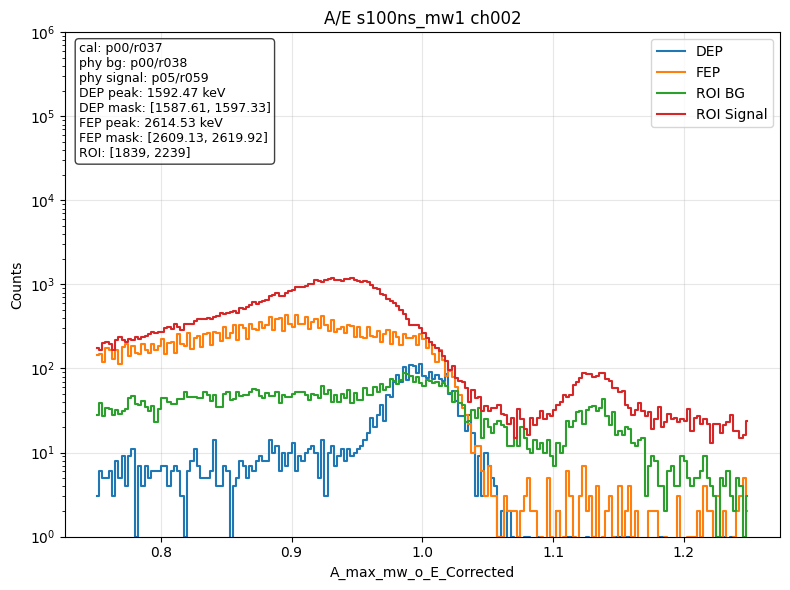


========== processing s100ns_mw3 ==========
--- s100ns_mw3 | ch002 ---


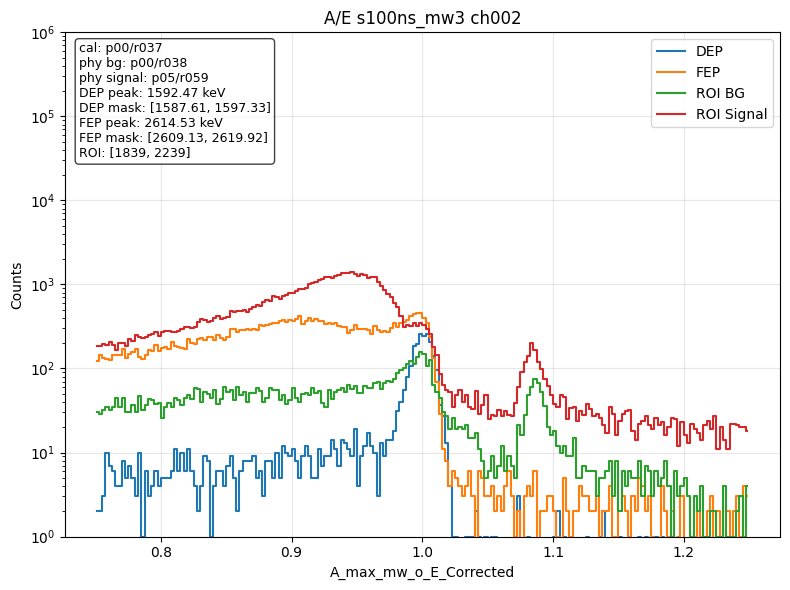


========== processing s100ns_mw5 ==========
--- s100ns_mw5 | ch002 ---


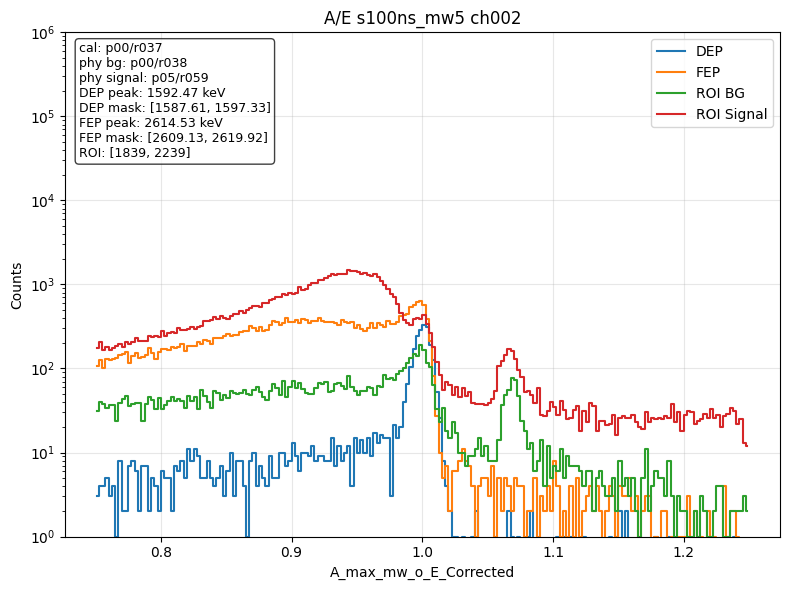


========== processing s100ns_mw7 ==========
--- s100ns_mw7 | ch002 ---


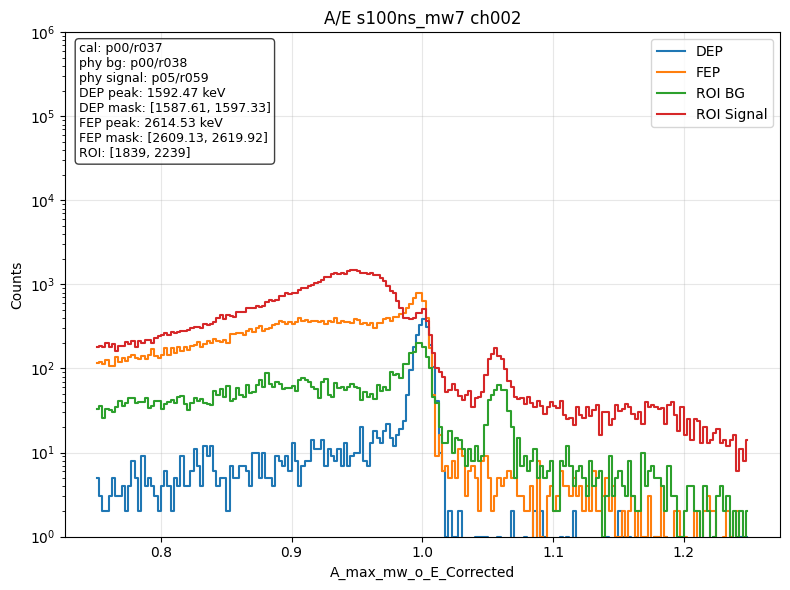


========== processing s200ns_mw1 ==========
--- s200ns_mw1 | ch002 ---


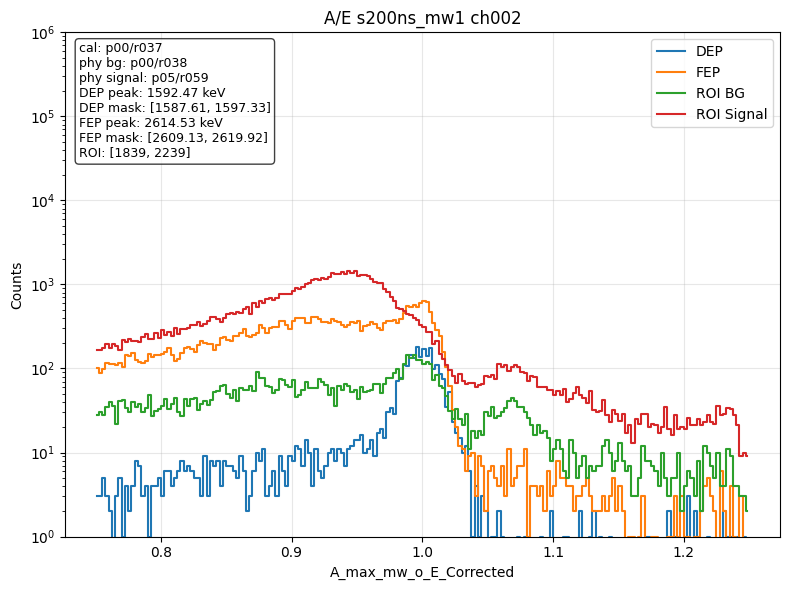


========== processing s200ns_mw3 ==========
--- s200ns_mw3 | ch002 ---


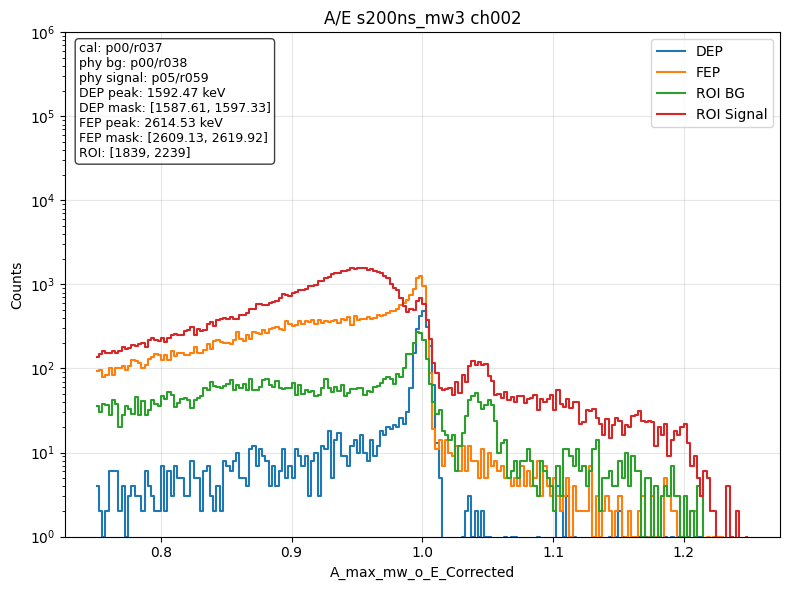


========== processing s200ns_mw5 ==========
--- s200ns_mw5 | ch002 ---


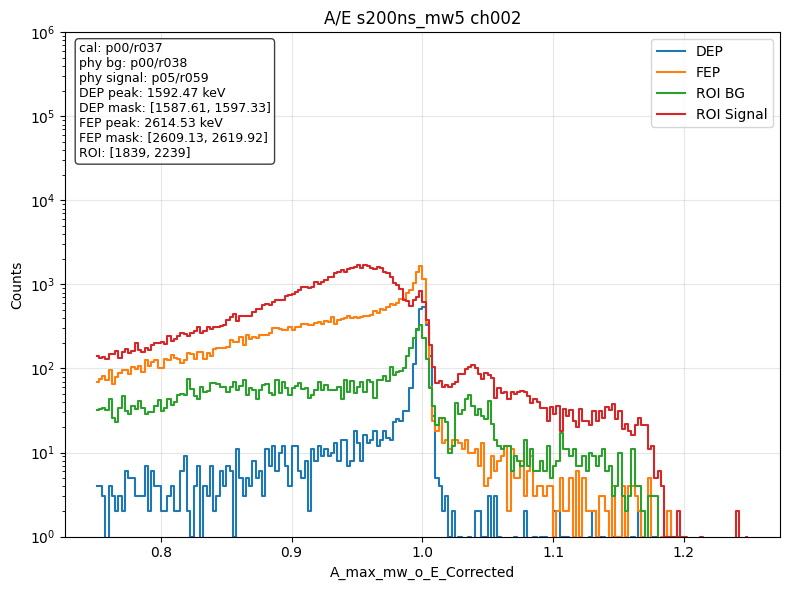


========== processing s200ns_mw7 ==========
--- s200ns_mw7 | ch002 ---


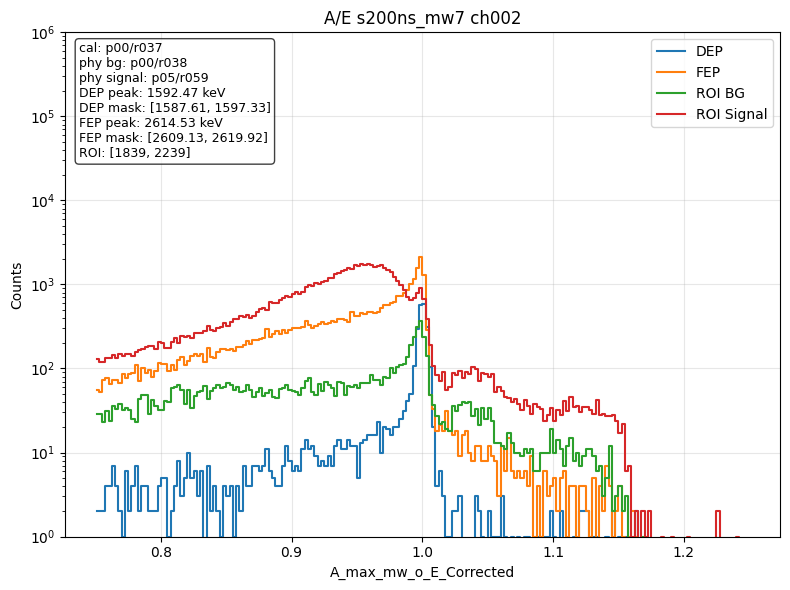


========== processing s60ns_mw1 ==========
--- s60ns_mw1 | ch002 ---


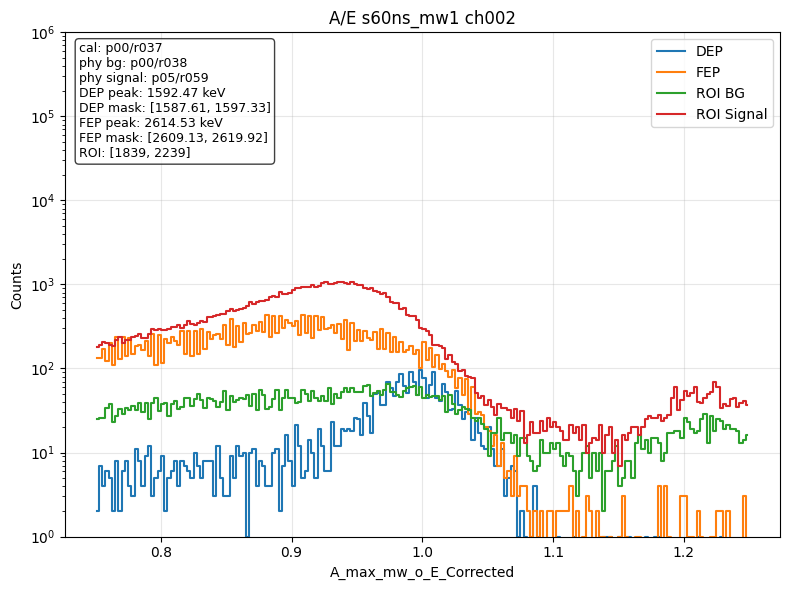


========== processing s60ns_mw3 ==========
--- s60ns_mw3 | ch002 ---


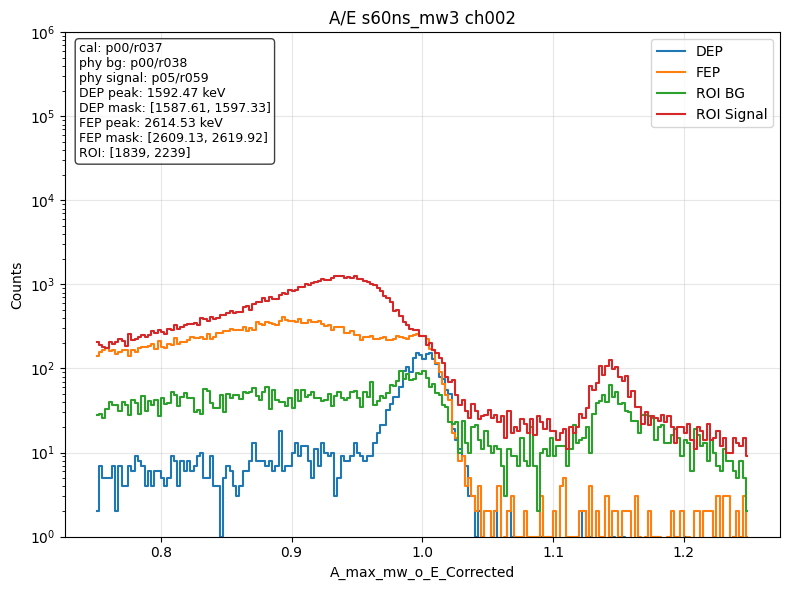


========== processing s60ns_mw5 ==========
--- s60ns_mw5 | ch002 ---


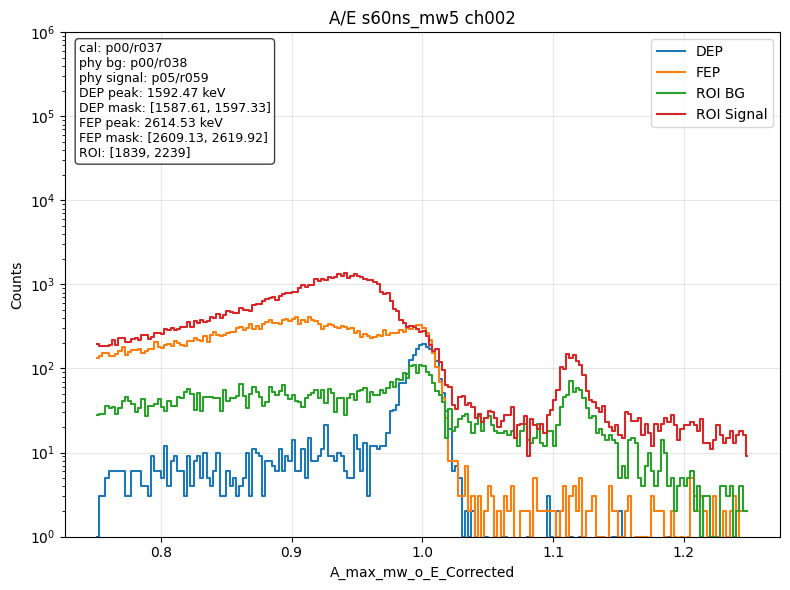


========== processing s60ns_mw7 ==========
--- s60ns_mw7 | ch002 ---


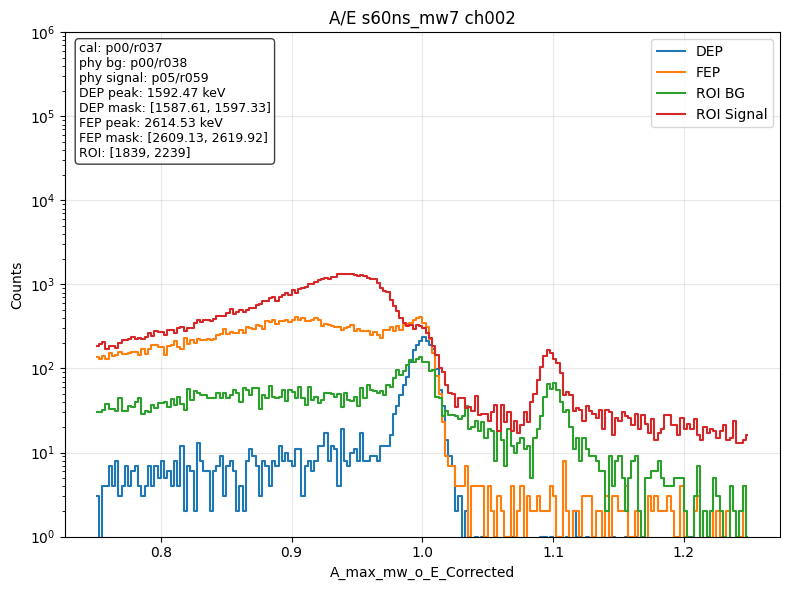

In [13]:
ch2_results = run_all_aoe_plots(
    run_db=run_db,
    lh5=lh5,
    indices=(1,),
    do_peak_plot=False,
    use_fitted_peaks=True,
    binnum=200,
    ylim_top=1e6,
    aoe_field="A_max_mw_o_E_Corrected",
    energy_field="trapEftp_cal",
),

In [15]:
import pickle
with open("ch2_aoe_results.pkl", "wb") as f:
    pickle.dump(ch2_results, f)

In [7]:
import pickle
# with open("single_hist.pkl", "rb") as f:
#     hist_db = pickle.load(f)

In [10]:
h = all_aoe_results['s100ns_mw3']['ch001']['hist_db']['DEP']
print(h.keys())

dict_keys(['counts', 'edges', 'centers', 'n_total'])


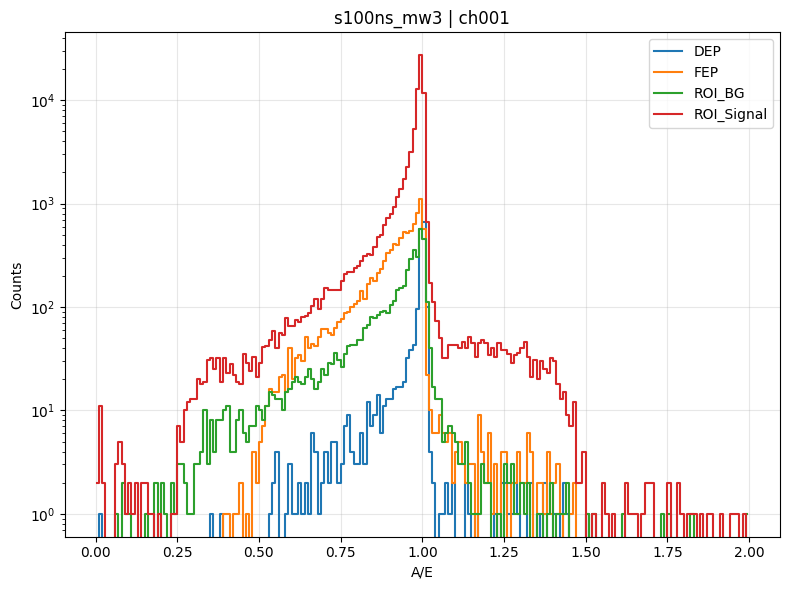

In [15]:
import matplotlib.pyplot as plt
h = all_aoe_results["s100ns_mw3"]["ch001"]
import matplotlib.pyplot as plt

hist_db = h["hist_db"]

plt.figure(figsize=(8, 6))

for label in ["DEP", "FEP", "ROI_BG", "ROI_Signal"]:
    plt.step(
        hist_db[label]["centers"],
        hist_db[label]["counts"],
        where="mid",
        label=label
    )

plt.yscale("log")
plt.xlabel(hist_db["meta"].get("aoe_field", "A/E"))
plt.ylabel("Counts")
plt.title(f'{hist_db["meta"]["run"]} | {hist_db["meta"]["channel"]}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 常见报错排查

### 1. `ModuleNotFoundError: No module named 'aoe_analysis_refactor'`
- 说明 `.py` 文件不在 notebook 当前目录
- 用 `sys.path.append(...)` 加路径

### 2. `field not found`
- 先运行字段检查 cell
- 确认到底是 `A_max_mw_o_E_Corrected` 还是别的名字

### 3. `run not found`
- 检查 `run_db.keys()`
- 该函数要求的 run 格式通常是 `s100ns_mw3`

### 4. 长度不一致 warning
- 说明同一个文件里能量和 A/E 字段长度不一样
- 当前版本会自动截到较短长度继续跑


## 现在看看survival fraction